In [8]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd

# Descargar datos de Itaú Corpbanca
# Nota: Itaú Corpbanca fue adquirida en 2008. Intentaremos con ITUB (Itaubank principal)
ticker = "ITUB4.SA"  # Itaú Unibanco (el principal)
start_date = "2021-03-09"
end_date = "2021-04-25"

data = yf.download(ticker, start=start_date, end=end_date)

# Convertir columnas OHLCV a float y eliminar NaN
data[['Open', 'High', 'Low', 'Close', 'Volume']] = data[['Open', 'High', 'Low', 'Close', 'Volume']].astype('float64')
data = data.dropna()

# Simplificar nombres de columnas (mplfinance espera Open, High, Low, Close, Volume)
data.columns = data.columns.droplevel(1) if data.columns.nlevels > 1 else data.columns

print(f"Datos descargados para {ticker}")
print(f"Rango de fechas: {start_date} a {end_date}")
print(f"Número de registros: {len(data)}")
print("\nPrimeros datos:")
print(data.head())
print("\nTipos de datos:")
print(data.dtypes)

[*********************100%***********************]  1 of 1 completed

Datos descargados para ITUB4.SA
Rango de fechas: 2021-03-09 a 2021-04-25
Número de registros: 32

Primeros datos:
Price           Close       High        Low       Open      Volume
Date                                                              
2021-03-09  17.391336  17.673497  16.897556  17.070700  42477076.0
2021-03-10  17.519602  17.628618  17.064297  17.384934  42320722.0
2021-03-11  17.545246  17.878709  17.301563  17.699153  39134159.0
2021-03-12  17.429821  17.641441  17.352868  17.410583  27834637.0
2021-03-15  17.635025  17.692738  17.301562  17.410579  31826649.0

Tipos de datos:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object


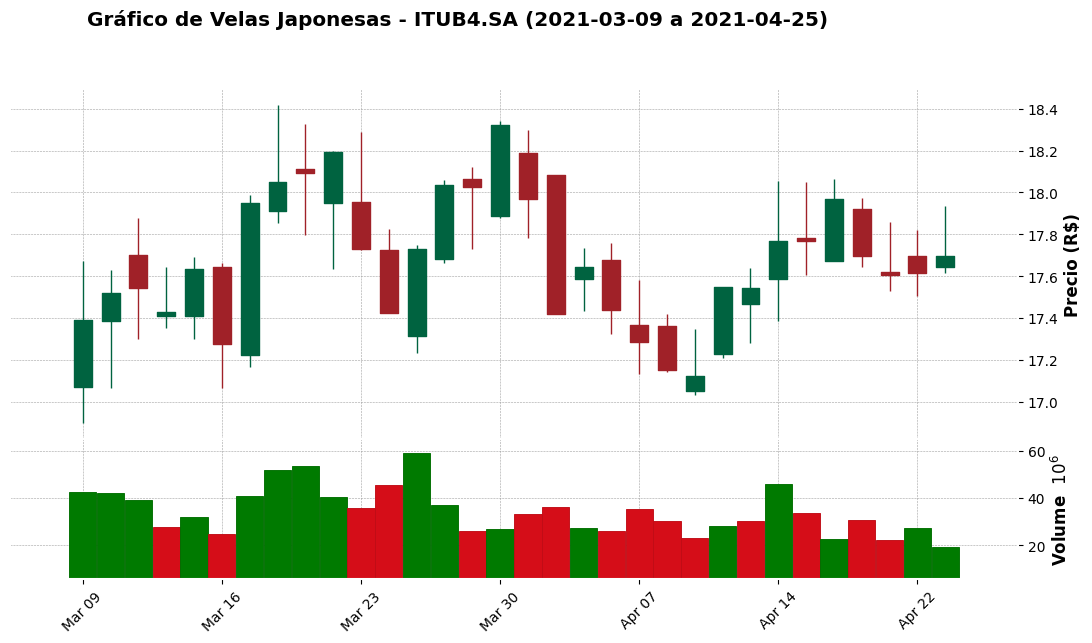

In [9]:
# Preparar datos para mplfinance (simplificar nombres de columnas)
data_plot = data.copy()
data_plot.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
data_plot = data_plot[['Open', 'High', 'Low', 'Close', 'Volume']]

# Crear gráfico de velas japonesas (candlestick chart)
mpf.plot(data_plot, 
         type='candle',  # Tipo de gráfico: velas japonesas
         style='charles',  # Estilo del gráfico
         title=f'Gráfico de Velas Japonesas - {ticker} ({start_date} a {end_date})',
         ylabel='Precio (R$)',
         volume=True,  # Mostrar volumen de transacciones
         figsize=(14, 7))